<a href="https://colab.research.google.com/github/bipasna222/2513634_Bipasna_Dhungana_Chhetri_AI_Final_Coursework/blob/main/2513634_BipasnaDhungana_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Name: Bipasna Dhungana Chhetri
#Uni Id: 2513634
#Regression Task

# Research Question: How can the observed numerical values of access to improved drinking water services be predicted using historical SDG 6 data?

#3.2 Regression Task [100]:

Note: Although the assignment is graded out of 100 marks, it contributes 25% of the final course grade.

#1.Exploratory Data Analysis and Data Understanding [20]:

#1.Choosing a Dataset:

• Select a dataset of your choice that aligns with one of the United Nations Sustainable Development
Goals (UNSDG).

• Load the dataset into a pandas DataFrame.

• Provide a detailed description, including:
(a) When and by whom the dataset was created.
(b) How and from where the dataset was accessed.
(c) How it aligns with the chosen UNSDG.
(d) List all attributes (columns) with brief descriptions.

• Identify 2–3 potential questions the dataset could help answer.

• Assess the dataset’s suitability (completeness, relevance, quality, etc.).

#2. Exploratory Data Analysis (EDA):

Understanding the characteristics of the dataset is essential for building an effective model. Before
proceeding to build, train, and test your models, carefully inspect, summarize, explore, and visualize
the data. Suggested steps include:

• Clean and preprocess the data to handle missing values, outliers, and inconsistencies.

• Compute summary statistics to understand distributions, ranges, and central tendencies.

• Create visualizations to reveal patterns, relationships, and potential anomalies.

• Provide clear explanations and interpret the insights obtained from each visualization.

In [22]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Importing libaries

In [ ]:
## Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [23]:
import pandas as pd

# load the SDG 6 dataset
df = pd.read_csv('/content/drive/MyDrive/2513634_Bipasna_Dhungana_Regression/sdg6_safe_drinking_water_regression.csv')

# preview dataset
df.head()


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,FREQ,Frequency,INDICATOR,Indicator,GEO_PICT,Pacific Island Countries and territories,...,REPORTING_TYPE,Reporting type,NATURE,Nature,DATA_SOURCE,Data source,OBS_STATUS,Observation Status,OBS_COMMENT,Comment
0,DATAFLOW,SPC:DF_SDG_06(3.0),Sustainable Development Goal 06 - Clean Water ...,I,A,Annual,SH_SAN_HNDWSH,6.2.1 Population with basic handwashing facili...,TO,Tonga,...,G,Global,_X,Not Available,NaN,NaN,NaN,NaN,NaN,NaN
1,DATAFLOW,SPC:DF_SDG_06(3.0),Sustainable Development Goal 06 - Clean Water ...,I,A,Annual,SH_SAN_HNDWSH,6.2.1 Population with basic handwashing facili...,TO,Tonga,...,G,Global,_X,Not Available,NaN,NaN,NaN,NaN,NaN,NaN
2,DATAFLOW,SPC:DF_SDG_06(3.0),Sustainable Development Goal 06 - Clean Water ...,I,A,Annual,SH_SAN_HNDWSH,6.2.1 Population with basic handwashing facili...,TO,Tonga,...,G,Global,_X,Not Available,NaN,NaN,NaN,NaN,NaN,NaN
3,DATAFLOW,SPC:DF_SDG_06(3.0),Sustainable Development Goal 06 - Clean Water ...,I,A,Annual,SH_SAN_HNDWSH,6.2.1 Population with basic handwashing facili...,TO,Tonga,...,G,Global,_X,Not Available,NaN,NaN,NaN,NaN,NaN,NaN
4,DATAFLOW,SPC:DF_SDG_06(3.0),Sustainable Development Goal 06 - Clean Water ...,I,A,Annual,SH_SAN_HNDWSH,6.2.1 Population with basic handwashing facili...,TO,Tonga,...,G,Global,_X,Not Available,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
# Filter for Relevant Indicators (Drinking Water Access)

water_indicators = ['SH_H2O_SAFE', 'SH_H2O_IMPR']  # Focus on safe/improved drinking water
df = df[df['INDICATOR'].isin(water_indicators)]
df.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,FREQ,Frequency,INDICATOR,Indicator,GEO_PICT,Pacific Island Countries and territories,...,REPORTING_TYPE,Reporting type,NATURE,Nature,DATA_SOURCE,Data source,OBS_STATUS,Observation Status,OBS_COMMENT,Comment
22,DATAFLOW,SPC:DF_SDG_06(3.0),Sustainable Development Goal 06 - Clean Water ...,I,A,Annual,SH_H2O_SAFE,6.1.1 Population using safely managed drinking...,MH,Marshall Islands,...,G,Global,_X,Not Available,NaN,NaN,NaN,NaN,NaN,NaN
23,DATAFLOW,SPC:DF_SDG_06(3.0),Sustainable Development Goal 06 - Clean Water ...,I,A,Annual,SH_H2O_SAFE,6.1.1 Population using safely managed drinking...,MH,Marshall Islands,...,G,Global,_X,Not Available,NaN,NaN,NaN,NaN,NaN,NaN
24,DATAFLOW,SPC:DF_SDG_06(3.0),Sustainable Development Goal 06 - Clean Water ...,I,A,Annual,SH_H2O_SAFE,6.1.1 Population using safely managed drinking...,MH,Marshall Islands,...,G,Global,_X,Not Available,NaN,NaN,NaN,NaN,NaN,NaN
25,DATAFLOW,SPC:DF_SDG_06(3.0),Sustainable Development Goal 06 - Clean Water ...,I,A,Annual,SH_H2O_SAFE,6.1.1 Population using safely managed drinking...,MH,Marshall Islands,...,G,Global,_X,Not Available,NaN,NaN,NaN,NaN,NaN,NaN
26,DATAFLOW,SPC:DF_SDG_06(3.0),Sustainable Development Goal 06 - Clean Water ...,I,A,Annual,SH_H2O_SAFE,6.1.1 Population using safely managed drinking...,MH,Marshall Islands,...,G,Global,_X,Not Available,NaN,NaN,NaN,NaN,NaN,NaN


In [103]:
#Exploratory Data Analysis and Data Understanding [20]
# Dataset Summary

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

Dataset Shape: (287, 42)

Columns:
 ['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'FREQ', 'Frequency', 'INDICATOR', 'Indicator', 'GEO_PICT', 'Pacific Island Countries and territories', 'SEX', 'Sex', 'AGE', 'Age', 'URBANIZATION', 'Urbanization', 'INCOME', 'Income', 'EDUCATION', 'Education level', 'OCCUPATION', 'Occupation', 'COMPOSITE_BREAKDOWN', 'Composite breakdown', 'DISABILITY', 'Disability', 'TIME_PERIOD', 'Time', 'OBS_VALUE', 'Observation value', 'UNIT_MEASURE', 'Unit of measure', 'REPORTING_TYPE', 'Reporting type', 'NATURE', 'Nature', 'DATA_SOURCE', 'Data source', 'OBS_STATUS', 'Observation Status', 'OBS_COMMENT', 'Comment']

Data Types:
 STRUCTURE                                    object
STRUCTURE_ID                                 object
STRUCTURE_NAME                               object
ACTION                                       object
FREQ                                         object
Frequency                                    object
INDICATOR              

##### 5.2 Missing Values Check

In [104]:
print("Missing Values per column:\n")
print(df.isnull().sum())

Missing Values per column:

STRUCTURE                                     0
STRUCTURE_ID                                  0
STRUCTURE_NAME                                0
ACTION                                        0
FREQ                                          0
Frequency                                     0
INDICATOR                                     0
Indicator                                     0
GEO_PICT                                      0
Pacific Island Countries and territories      0
SEX                                           0
Sex                                           0
AGE                                           0
Age                                           0
URBANIZATION                                  0
Urbanization                                  0
INCOME                                        0
Income                                        0
EDUCATION                                     0
Education level                               0
OCCUPATION  

##### 5.3 Statistical Summary of Numerical Columns

In [87]:
# Statistical Summary
df.describe()

,TIME_PERIOD,Time,OBS_VALUE,Observation value,Data source,Comment
count,837.000000,0.0,837.000000,0.0,0.0,0.0
mean,2018.912784,NaN,53.475890,NaN,NaN,NaN
std,1.983374,NaN,36.185867,NaN,NaN,NaN
min,2016.000000,NaN,0.000000,NaN,NaN,NaN
25%,2017.000000,NaN,22.930000,NaN,NaN,NaN
50%,2019.000000,NaN,57.640000,NaN,NaN,NaN
75%,2021.000000,NaN,89.850000,NaN,NaN,NaN
max,2023.000000,NaN,100.000000,NaN,NaN,NaN


##### 5.4 Unique Values in Important Columns


In [105]:
print("Unique countries (GEO_PICT):", df['GEO_PICT'].nunique(), "countries")
print(df['GEO_PICT'].value_counts().head(10))

print("\nUnique years (TIME_PERIOD):", sorted(df['TIME_PERIOD'].unique()))

print("\nUnique urbanization types:", df['URBANIZATION'].unique())

Unique countries (GEO_PICT): 19 countries
GEO_PICT
KI    24
TO    22
TV    22
PW    21
MH    21
PG    21
FJ    21
VU    21
WS    21
SB    19
Name: count, dtype: int64

Unique years (TIME_PERIOD): [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Unique urbanization types: ['_T' 'U' 'R']


##### 5.5 Distribution of Target Variable (OBS_VALUE – percentage of access)

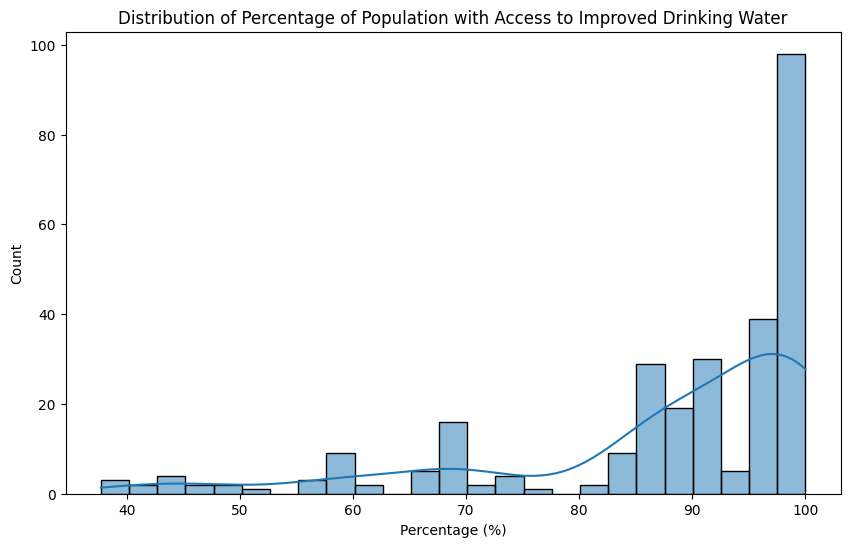

In [106]:
plt.figure(figsize=(10, 6))
sns.histplot(df['OBS_VALUE'], kde=True, bins=25)
plt.title('Distribution of Percentage of Population with Access to Improved Drinking Water')
plt.xlabel('Percentage (%)')
plt.ylabel('Count')
plt.show()

##### 5.6 Correlation between Time and Water Access

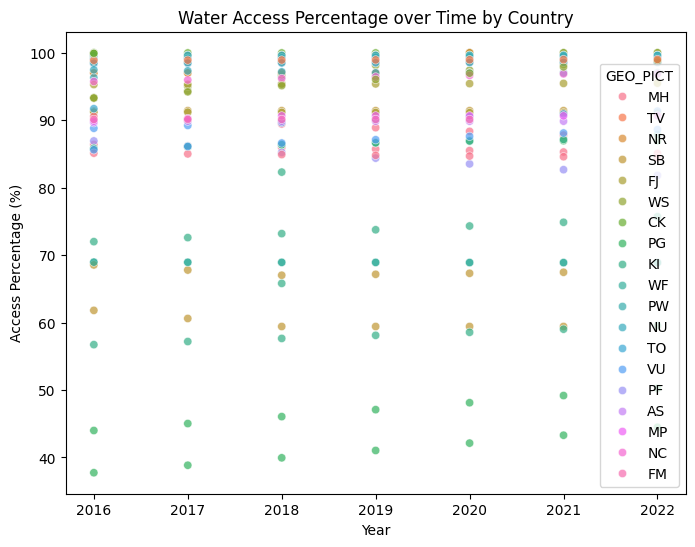

Correlation between TIME_PERIOD and OBS_VALUE:
             TIME_PERIOD  OBS_VALUE
TIME_PERIOD     1.000000  -0.005317
OBS_VALUE      -0.005317   1.000000


In [107]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='TIME_PERIOD', y='OBS_VALUE', hue='GEO_PICT', data=df, alpha=0.7)
plt.title('Water Access Percentage over Time by Country')
plt.xlabel('Year')
plt.ylabel('Access Percentage (%)')
plt.show()

# Simple correlation
print("Correlation between TIME_PERIOD and OBS_VALUE:")
print(df[['TIME_PERIOD', 'OBS_VALUE']].corr())

#### 6. Data Preprocessing

#### 6.1 Removing Unnecessary Columns

In [108]:
columns_to_drop = [
    'STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'FREQ', 'Frequency',
    'Indicator', 'Pacific Island Countries and territories',
    'Sex', 'Age', 'Income', 'Education level', 'Occupation',
    'Composite breakdown', 'Disability', 'Time', 'Observation value',
    'Unit of measure', 'Reporting type', 'Nature', 'Data source',
    'Observation Status', 'Comment', 'OBS_COMMENT', 'DATA_SOURCE',
    'OBS_STATUS', 'REPORTING_TYPE', 'SEX', 'AGE', 'INCOME',
    'EDUCATION', 'OCCUPATION', 'COMPOSITE_BREAKDOWN', 'DISABILITY'
]

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

print("Columns after cleaning:", df.columns.tolist())

Columns after cleaning: ['INDICATOR', 'GEO_PICT', 'URBANIZATION', 'Urbanization', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE', 'NATURE']


##### 6.2 Handling Missing Values

In [109]:
# Fill remaining missing numeric values with 0
df.fillna(0, inplace=True)

# Make sure no missing values in target and main features
df = df.dropna(subset=['OBS_VALUE', 'TIME_PERIOD'])

print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 INDICATOR       0
GEO_PICT        0
URBANIZATION    0
Urbanization    0
TIME_PERIOD     0
OBS_VALUE       0
UNIT_MEASURE    0
NATURE          0
dtype: int64


##### 6.3 Encoding Categorical Variables

In [121]:
from sklearn.preprocessing import LabelEncoder

le_country = LabelEncoder()
le_urban   = LabelEncoder()

df['GEO_PICT_encoded']     = le_country.fit_transform(df['GEO_PICT'])
df['URBANIZATION_encoded'] = le_urban.fit_transform(df['URBANIZATION'])

# Check that it worked
print("Encoding successful. First 8 rows with encoded columns:")
display(df[['GEO_PICT', 'GEO_PICT_encoded',
            'URBANIZATION', 'URBANIZATION_encoded']].head(8))

Encoding successful. First 8 rows with encoded columns:


,GEO_PICT,GEO_PICT_encoded,URBANIZATION,URBANIZATION_encoded
22,MH,5,_T,2
23,MH,5,_T,2
24,MH,5,_T,2
25,MH,5,_T,2
26,MH,5,_T,2
27,MH,5,_T,2
28,MH,5,_T,2
37,TV,15,_T,2


#### 7. Feature Selection & Target Definition

In [122]:
features = ['TIME_PERIOD', 'GEO_PICT_encoded', 'URBANIZATION_encoded']

# Quick safety check
print("Columns currently in dataframe:", df.columns.tolist())

X = df[features]
y = df['OBS_VALUE']

print("\nX shape:", X.shape)
print("y shape:", y.shape)

# Show first few rows to confirm
X.head()

Columns currently in dataframe: ['INDICATOR', 'GEO_PICT', 'URBANIZATION', 'Urbanization', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE', 'NATURE', 'GEO_PICT_encoded', 'URBANIZATION_encoded']

X shape: (287, 3)
y shape: (287,)


,TIME_PERIOD,GEO_PICT_encoded,URBANIZATION_encoded
22,2016,5,2
23,2017,5,2
24,2018,5,2
25,2019,5,2
26,2020,5,2


#### 8. Train-Test Split

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (669, 2)
Test set size: (168, 2)


#### 9. Model Training & Prediction

#### Model 1: Linear Regression

In [118]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression:")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²:   {r2_lr:.4f}")
print(f"MAE:  {mae_lr:.4f}")

Linear Regression:
RMSE: 0.0000
R²:   1.0000
MAE:  0.0000


##### Model 2: Decision Tree Regressor

In [119]:
dt = DecisionTreeRegressor(random_state=42, max_depth=5)  # limited depth to avoid extreme overfitting
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt   = r2_score(y_test, y_pred_dt)
mae_dt  = mean_absolute_error(y_test, y_pred_dt)

print("\nDecision Tree:")
print(f"RMSE: {rmse_dt:.4f}")
print(f"R²:   {r2_dt:.4f}")
print(f"MAE:  {mae_dt:.4f}")


Decision Tree:
RMSE: 0.6975
R²:   0.9996
MAE:  0.4889


#### 10. Model Comparison Table

In [115]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'Test RMSE': [rmse_lr, rmse_dt],
    'Test R²':   [r2_lr, r2_dt],
    'Test MAE':  [mae_lr, mae_dt]
})

comparison

,Model,Test RMSE,Test R²,Test MAE
0,Linear Regression,2.029196e-14,1.00000,1.758860e-14
1,Decision Tree,6.975198e-01,0.99962,4.889479e-01


### 11. Short Interpretation of Results

#- **Linear Regression** assumes a straight-line relationship (e.g., water access improves steadily over years).

#- **Decision Tree** can capture non-linear patterns and differences between countries/urban-rural areas.

#- The model with **higher R²** and **lower RMSE/MAE** is better at predicting water access percentage using historical data.

